# QA — Reconciliation Metabase vs Adjust (CDS Android)

Notebook orchestration: gọi `clients/` để lấy data, gọi `reconciliation/` để xử lý.
Toàn bộ logic thật nằm trong 2 package đó — sửa logic ở đó, không sửa ở đây.

Đối chiếu đủ 12 chỉ số: ROAS D0-D28, Revenue D0-D28, Cost, Installs — sai số tương đối
thống nhất `ratio = mb/adj`, ngưỡng `config.THRESHOLD_PCT`. Cohort chưa đủ maturity theo
`Cohort Age` bị loại khỏi so sánh tự động.

In [10]:
import sys
sys.path.append("..")

import config
import run_config as rc
from clients.adjust_client import AdjustClient
from clients.metabase_client import MetabaseClient
from reconciliation.normalize import normalize_metabase, normalize_adjust, filter_excluded_dates
from reconciliation.merge import merge_sources, report_join_gaps
from reconciliation.flags import build_detail
from reconciliation.summary import summarize, top_discrepancy
from reconciliation import eda

Matplotlib is building the font cache; this may take a moment.


## 0. (Tuỳ chọn) Override config riêng cho lần chạy này

`config.EXCLUDED_DATES` và `config.DATA_ASOF_DATE` là kiến thức riêng theo từng lần chạy
(ngày nào bị lỗi, chốt dữ liệu vào lúc nào) — override trực tiếp ở đây thay vì sửa `config.py`
nếu chỉ dùng cho 1 lần đối chiếu cụ thể.

In [2]:
# Toàn bộ lựa chọn cho lần chạy này đến từ run_config.py — sửa ở đó, không sửa ở đây.
game = config.GAMES[rc.GAME_KEY]
adjust_app_token = config.get_adjust_app_token(rc.GAME_KEY)

config.EXCLUDED_DATES = rc.EXCLUDED_DATES
config.DATA_ASOF_DATE = rc.DATA_ASOF_DATE

# 1 nguồn duy nhất cho khoảng ngày -> tự format đúng cho cả 2 API,
# không còn rủi ro sửa 1 chỗ quên chỗ kia.
metabase_date_range = f"{rc.DATE_PERIOD_START}~{rc.DATE_PERIOD_END}"
adjust_date_period = f"{rc.DATE_PERIOD_START}:{rc.DATE_PERIOD_END}"

print(f"Đang chạy cho: {game['label']}")
print(f"Khoảng ngày: {rc.DATE_PERIOD_START} -> {rc.DATE_PERIOD_END}")
print(f"EXCLUDED_DATES: {rc.EXCLUDED_DATES or '(không có)'}")
print(f"DATA_ASOF_DATE: {rc.DATA_ASOF_DATE or '(dùng ngày hệ thống hiện tại)'}")

Đang chạy cho: Game A (CDS) — Android
Khoảng ngày: 2026-07-19 -> 2026-09-06
EXCLUDED_DATES: ['2026-09-05']
DATA_ASOF_DATE: 2026-09-06


## 1. Lấy dữ liệu Metabase

In [3]:
mb = MetabaseClient(base_url=config.METABASE_URL, api_key=config.METABASE_API_KEY)

parameters = mb.build_parameters(
    game["metabase_card_id"],
    cohort_date=metabase_date_range,
    game=game["metabase_game"],
    platform=game["metabase_platform"],
    active_only=[True],
)

df_mb = mb.query_card(game["metabase_card_id"], parameters)
print("Số dòng Metabase:", df_mb.shape[0])
df_mb.head()

Số dòng Metabase: 178


,Cohort Date,Game,Platform,Network,Campaign,Cost,Adjust Installs,CPI,ROAS D0,ROAS D3,ROAS D7,ROAS D14,ROAS D28,Revenue D0,Revenue D3,Revenue D7,Revenue D14,Revenue D28,Revenue Complete Through
0,2026-09-06T00:00:00Z,Game A,ANDROID,APPLOVIN,CDS Android - D28 AdROAS - 260131,8348.528646,5737,1.455208,0.033592,NaN,NaN,NaN,NaN,280.444990,NaN,NaN,NaN,NaN,2026-09-06T00:00:00Z
1,2026-09-06T00:00:00Z,Game A,ANDROID,APPLOVIN,CDS Android - D28 BLDROAS - 260406,2738.313183,886,3.090647,0.035724,NaN,NaN,NaN,NaN,97.822905,NaN,NaN,NaN,NaN,2026-09-06T00:00:00Z
2,2026-09-06T00:00:00Z,Game A,ANDROID,APPLOVIN,CDS Android - D28 AdROAS - Localize - 260813,264.940749,122,2.171645,0.058106,NaN,NaN,NaN,NaN,15.394588,NaN,NaN,NaN,NaN,2026-09-06T00:00:00Z
3,2026-09-05T00:00:00Z,Game A,ANDROID,APPLOVIN,CDS Android - D28 AdROAS - 260131,7038.951463,0,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,2026-09-06T00:00:00Z
4,2026-09-05T00:00:00Z,Game A,ANDROID,APPLOVIN,CDS Android - D28 BLDROAS - 260406,1932.687983,0,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,2026-09-06T00:00:00Z


## 2. Lấy dữ liệu Adjust
Dùng `config.ADJUST_METRICS_CDS_ANDROID` — đã gồm đủ Installs, Cost, ROAS D0-D28, Revenue D0-D28.

In [4]:
adjust = AdjustClient(api_token=config.ADJUST_API_TOKEN)

df_adjust, adjust_totals = adjust.fetch_report(
    app_token=adjust_app_token,
    dimensions=["day", "network", "campaign_network"],
    metrics=config.ADJUST_METRICS,
    date_period=adjust_date_period,
    extra_params=game["adjust_extra_params"],
)
print("Số dòng Adjust:", df_adjust.shape[0])
print("Totals:", adjust_totals)
df_adjust.head()

Số dòng Adjust: 178
Totals: {'installs': 320591.0, 'network_cost': 781009.9287, 'roas_ad_cal_d0': 0.0665, 'roas_ad_cal_d3': 0.203, 'roas_ad_cal_d7': 0.2952, 'roas_ad_cal_d14': 0.3913, 'roas_ad_cal_d28': 0.5286, 'ad_revenue_total_cal_d0': 51909.7451, 'ad_revenue_total_cal_d3': 158532.3086, 'ad_revenue_total_cal_d7': 224486.1283, 'ad_revenue_total_cal_d14': 277240.23, 'ad_revenue_total_cal_d28': 275094.0205}


,day,network,campaign_network,installs,network_cost,roas_ad_cal_d0,roas_ad_cal_d3,roas_ad_cal_d7,roas_ad_cal_d14,roas_ad_cal_d28,ad_revenue_total_cal_d0,ad_revenue_total_cal_d3,ad_revenue_total_cal_d7,ad_revenue_total_cal_d14,ad_revenue_total_cal_d28
0,2026-07-19,ALV,CDS Android - D28 AdROAS - 260131,11058,29419.5335,0.1063,0.2446,0.352,0.4586,0.5882,3128.5357,7196.2161,10354.2524,13493.1398,17305.6663
1,2026-07-22,ALV,CDS Android - D28 AdROAS - 260131,9126,19393.6725,0.0648,0.2139,0.3116,0.4109,0.5231,1256.5267,4148.2075,6042.1257,7968.4531,10143.956
2,2026-07-21,ALV,CDS Android - D28 AdROAS - 260131,9105,22665.873,0.0699,0.2073,0.3001,0.3921,0.4961,1584.0079,4698.7017,6802.9475,8887.587,11244.2953
3,2026-07-20,ALV,CDS Android - D28 AdROAS - 260131,8716,20463.8374,0.0685,0.211,0.3058,0.3885,0.4997,1400.8628,4318.7356,6257.0909,7949.2316,10225.7733
4,2026-07-25,ALV,CDS Android - D28 AdROAS - 260131,7670,17552.6961,0.0819,0.256,0.3617,0.4696,0.6202,1437.3496,4493.6918,6348.4432,8242.3485,10886.354


## 3. Normalize + loại ngày lỗi + Merge

In [5]:
mb_norm = normalize_metabase(df_mb)
adj_norm = normalize_adjust(df_adjust)

mb_norm = filter_excluded_dates(mb_norm, config.EXCLUDED_DATES)
adj_norm = filter_excluded_dates(adj_norm, config.EXCLUDED_DATES)

merged = merge_sources(mb_norm, adj_norm)
join_stats = report_join_gaps(merged)


Đã loại 3 dòng thuộc các ngày bị exclude: [datetime.date(2026, 9, 5)]
Đã loại 3 dòng thuộc các ngày bị exclude: [datetime.date(2026, 9, 5)]
Khớp cả 2 nguồn: 175 dòng
Chỉ có ở Metabase: 0 dòng
Chỉ có ở Adjust: 0 dòng


## 4. Tính bảng đối chiếu chi tiết (long-format)
Mỗi dòng = 1 cohort x 1 metric. Dùng `merged` đầy đủ (kể cả phần lệch join key) —
các dòng đó tự ra flag "N/A (thiếu dữ liệu)", không bị âm thầm bỏ qua.

In [6]:
detail = build_detail(merged)
detail.head(10)


Cohort Age tính theo DATA_ASOF_DATE = 2026-09-06
EXCLUDE_IMMATURE_COHORTS = True
[CHỐT] Sai số tương đối ratio = mb/adj. Ngưỡng Discrepancy: |rel_diff_pct| > 5.0%

Bảng detail: 2100 dòng (= 175 cohort x 12 chỉ số)
Số dòng bị loại vì cohort chưa đủ maturity: 380


,cohort_date,network,campaign,metric,cohort_age_days,is_immature,mb_value,adjust_value,abs_diff,ratio,rel_diff_pct,flag
0,2026-07-19,APPLOVIN,CDS Android - D28 AdROAS - 260131,COST,49,False,29419.533620,29419.5335,0.000120,1.000000,0.0000,OK
1,2026-07-19,APPLOVIN,CDS Android - D28 BLDROAS - 260406,COST,49,False,5702.322294,5702.3223,-0.000006,1.000000,-0.0000,OK
2,2026-07-19,APPLOVIN,CDS Android - D28 AdROAS - 260131,INSTALLS,49,False,11191.000000,11058.0000,133.000000,1.012027,1.2027,OK
3,2026-07-19,APPLOVIN,CDS Android - D28 BLDROAS - 260406,INSTALLS,49,False,786.000000,665.0000,121.000000,1.181955,18.1955,Discrepancy
4,2026-07-19,APPLOVIN,CDS Android - D28 AdROAS - 260131,REVENUE_D0,49,False,3088.003170,3128.5357,-40.532530,0.987044,-1.2956,OK
5,2026-07-19,APPLOVIN,CDS Android - D28 BLDROAS - 260406,REVENUE_D0,49,False,452.132448,457.6449,-5.512452,0.987955,-1.2045,OK
6,2026-07-19,APPLOVIN,CDS Android - D28 AdROAS - 260131,REVENUE_D14,49,False,13096.713132,13493.1398,-396.426668,0.970620,-2.9380,OK
7,2026-07-19,APPLOVIN,CDS Android - D28 BLDROAS - 260406,REVENUE_D14,49,False,2561.573715,2607.5538,-45.980085,0.982367,-1.7633,OK
8,2026-07-19,APPLOVIN,CDS Android - D28 AdROAS - 260131,REVENUE_D28,49,False,16731.052507,17305.6663,-574.613793,0.966796,-3.3204,OK
9,2026-07-19,APPLOVIN,CDS Android - D28 BLDROAS - 260406,REVENUE_D28,49,False,3372.079570,3428.5224,-56.442830,0.983537,-1.6463,OK


## 5. Tổng hợp % Discrepancy — theo Campaign x Metric, và toàn hệ thống

In [7]:
summary_result = summarize(detail)
summary_by_campaign = summary_result["by_campaign"]
summary_overall = summary_result["overall"]


=== Tổng hợp theo từng Campaign ===
                                    campaign      metric  n_valid  mean_abs_diff  mean_ratio  mean_abs_rel_diff_pct  median_abs_rel_diff_pct  p90_abs_rel_diff_pct  pct_discrepancy
           CDS Android - D28 AdROAS - 260131     ROAS_D0       49         0.0034      0.9491                 5.0933                   2.8839                4.8536          10.2041
           CDS Android - D28 AdROAS - 260131     ROAS_D3       47         0.0103      0.9502                 4.9830                   3.8787                5.5306          23.4043
           CDS Android - D28 AdROAS - 260131     ROAS_D7       43         0.0143      0.9531                 4.6863                   4.1546                6.5037          32.5581
           CDS Android - D28 AdROAS - 260131    ROAS_D14       36         0.0196      0.9527                 4.7335                   4.3221                6.8286          33.3333
           CDS Android - D28 AdROAS - 260131    ROAS_D28       2

## 6. Top các dòng lệch nhiều nhất — ưu tiên kiểm tra trước

In [8]:
top = top_discrepancy(detail, top_n=20, per_campaign=5)

print("=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===")
display(top["top_overall"])

print("\n=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===")
display(top["top_per_campaign"])


=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
910,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,ROAS_D7,0.000000,0.0316,-0.031600,-100.0000
907,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,ROAS_D3,0.000000,0.0316,-0.031600,-100.0000
883,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,REVENUE_D0,0.000000,0.0152,-0.015200,-100.0000
886,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,REVENUE_D14,0.000000,0.0152,-0.015200,-100.0000
892,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,REVENUE_D3,0.000000,0.0152,-0.015200,-100.0000
895,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,REVENUE_D7,0.000000,0.0152,-0.015200,-100.0000
898,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,ROAS_D0,0.000000,0.0316,-0.031600,-100.0000
901,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,ROAS_D14,0.000000,0.0316,-0.031600,-100.0000
1787,2026-08-29,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,REVENUE_D0,0.000000,0.0173,-0.017300,-100.0000
1789,2026-08-29,APPLOVIN,CDS Android - D28 AdROAS - Weekend - 260724,REVENUE_D0,0.000000,0.0405,-0.040500,-100.0000



=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
2034,2026-09-04,APPLOVIN,CDS Android - D28 AdROAS - 260131,REVENUE_D0,189.056703,400.4815,-211.424797,-52.7927
2049,2026-09-04,APPLOVIN,CDS Android - D28 AdROAS - 260131,ROAS_D0,0.037958,0.0804,-0.042442,-52.7884
2085,2026-09-06,APPLOVIN,CDS Android - D28 AdROAS - 260131,ROAS_D0,0.033592,0.0589,-0.025308,-42.9675
2070,2026-09-06,APPLOVIN,CDS Android - D28 AdROAS - 260131,REVENUE_D0,280.444990,491.3490,-210.904010,-42.9235
2022,2026-09-03,APPLOVIN,CDS Android - D28 AdROAS - 260131,ROAS_D3,0.122027,0.1993,-0.077273,-38.7724
910,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,ROAS_D7,0.000000,0.0316,-0.031600,-100.0000
907,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,ROAS_D3,0.000000,0.0316,-0.031600,-100.0000
883,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,REVENUE_D0,0.000000,0.0152,-0.015200,-100.0000
886,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,REVENUE_D14,0.000000,0.0152,-0.015200,-100.0000
892,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,REVENUE_D3,0.000000,0.0152,-0.015200,-100.0000


## 7. (Tuỳ chọn) Xuất kết quả
Thêm cell ghi `detail`/`summary_by_campaign`/`summary_overall` ra BigQuery / Google Sheets /
`.docx` report tại đây, khi bạn đã sẵn sàng nối vào pipeline output hiện có.

```python
# detail.to_csv("../outputs/reconciliation_detail.csv", index=False, encoding="utf-8-sig")
# summary_by_campaign.to_csv("../outputs/reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
# summary_overall.to_csv("../outputs/reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")
```

In [9]:
from pathlib import Path

output_dir = Path("../outputs") / rc.GAME_KEY
output_dir.mkdir(parents=True, exist_ok=True)

detail.to_csv(output_dir / "reconciliation_detail.csv", index=False, encoding="utf-8-sig")
summary_by_campaign.to_csv(output_dir / "reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
summary_overall.to_csv(output_dir / "reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")

print(f"Đã xuất kết quả vào: {output_dir.resolve()}")

Đã xuất kết quả vào: D:\Document-D\2025.2\LabDATA\Game\QA\qa-pipeline\outputs\game_a_android


## 8. EDA — Phân tích trực quan

### 8.1. So sánh Tổng — Metabase vs Adjust
Tổng Cost/Installs/Revenue D0-D28 cộng dồn trên toàn bộ khoảng ngày đã chọn. Không gồm ROAS
(là tỷ lệ, cộng dồn không có ý nghĩa) — xem xu hướng ROAS ở mục 8.5.

=== So sánh TỔNG (cộng dồn toàn bộ khoảng ngày) ===
     metric      mb_total  adjust_total   n  rel_diff_pct
 REVENUE_D0  49462.339746    51332.1634 170     -3.642597
 REVENUE_D3 147642.186338   153149.0180 166     -3.595734
 REVENUE_D7 207794.904785   215710.8823 154     -3.669716
REVENUE_D14 251537.577602   261585.0212 123     -3.840986
REVENUE_D28 229834.078838   239274.2008  61     -3.945315
       COST 771818.193860   771818.1836 174      0.000001
   INSTALLS 320459.000000   316923.0000 174      1.115728


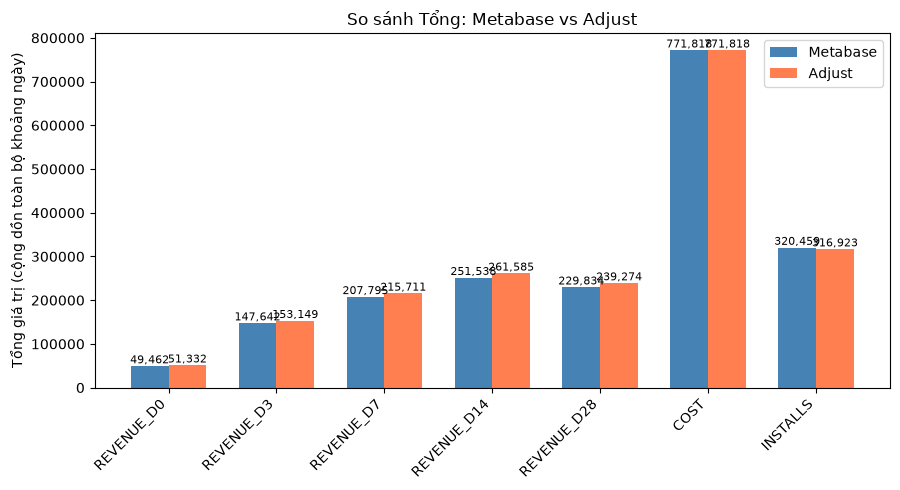

In [11]:
totals = eda.compare_totals(detail)
eda.plot_totals_comparison(totals)

### 8.2. Tổng quan Campaign
Số lượng Campaign đang đối chiếu, và số ngày (cohort) mỗi Campaign có dữ liệu — giúp phát hiện
nhanh Campaign nào có mẫu quá nhỏ, cần cẩn trọng khi đọc % Discrepancy.

Số lượng Campaign đang đối chiếu: 5
                                              n_days  first_date   last_date
campaign                                                                    
CDS Android - D28 AdROAS - 260131                 49  2026-07-19  2026-09-06
CDS Android - D28 BLDROAS - 260406                49  2026-07-19  2026-09-06
CDS Android - D28 AdROAS - CPM - 260727           35  2026-07-27  2026-08-30
CDS Android - D28 AdROAS - Weekend - 260724       22  2026-08-07  2026-08-29
CDS Android - D28 AdROAS - Localize - 260813      20  2026-08-17  2026-09-06


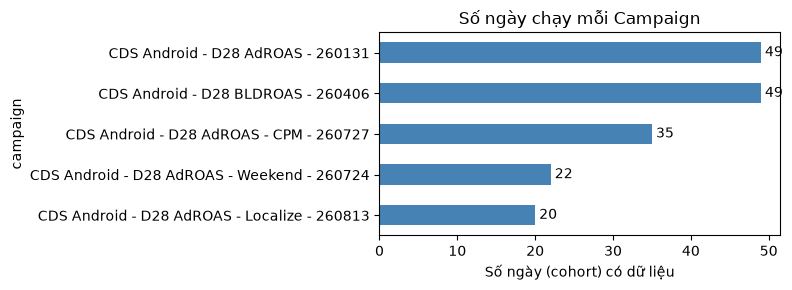

In [12]:
campaign_overview_df = eda.campaign_overview(detail)
eda.plot_campaign_overview(campaign_overview_df)

### 8.3. Heatmap % Discrepancy theo Campaign x Metric
Màu càng đỏ đậm, % Discrepancy càng cao — nhìn nhanh Campaign nào và Metric nào đang có vấn đề.

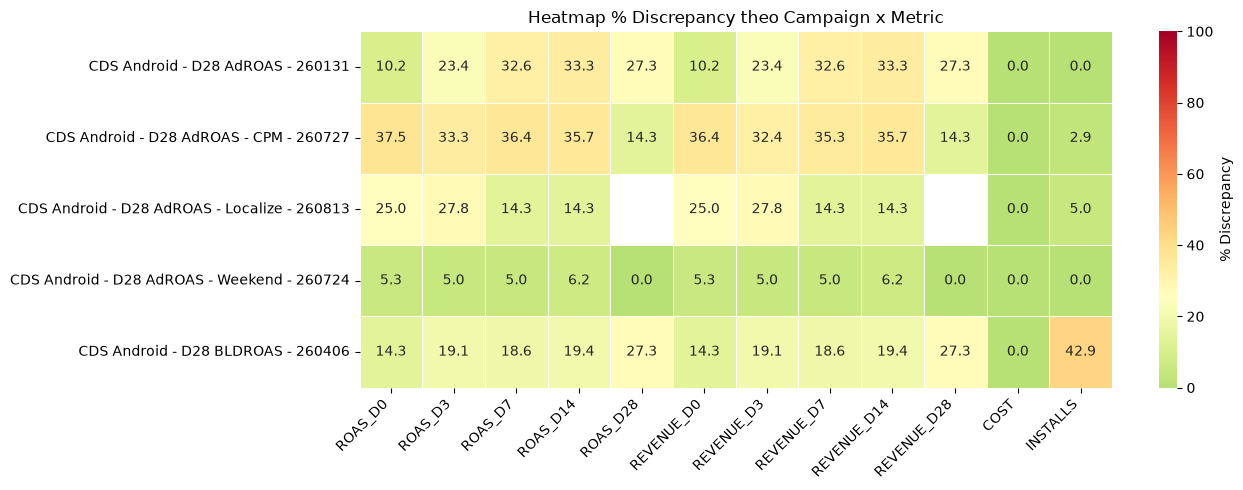

In [13]:
discrepancy_pivot = eda.plot_discrepancy_heatmap(summary_by_campaign)

### 8.4. Phân tích theo Metric — toàn hệ thống (gộp mọi Campaign)

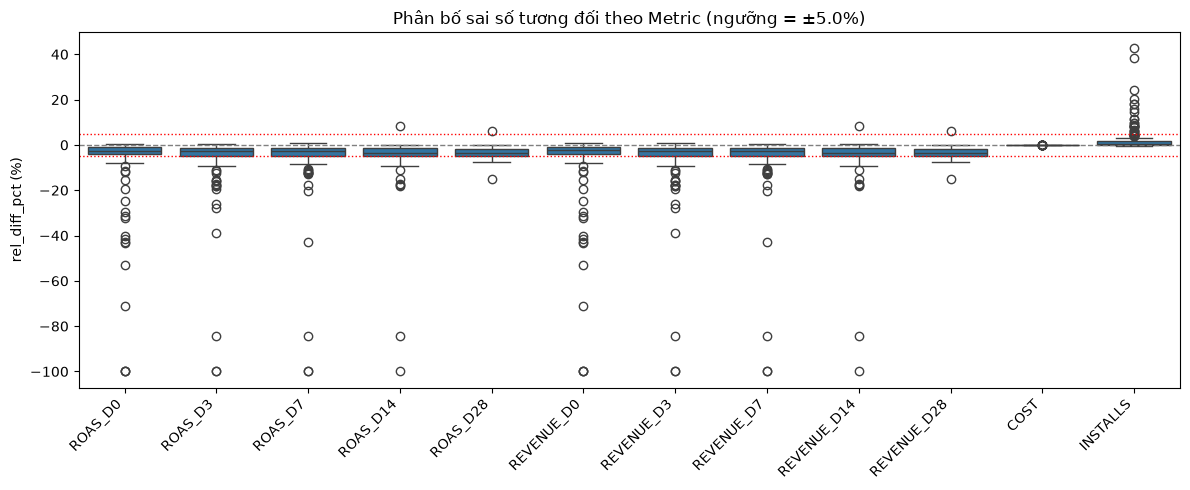

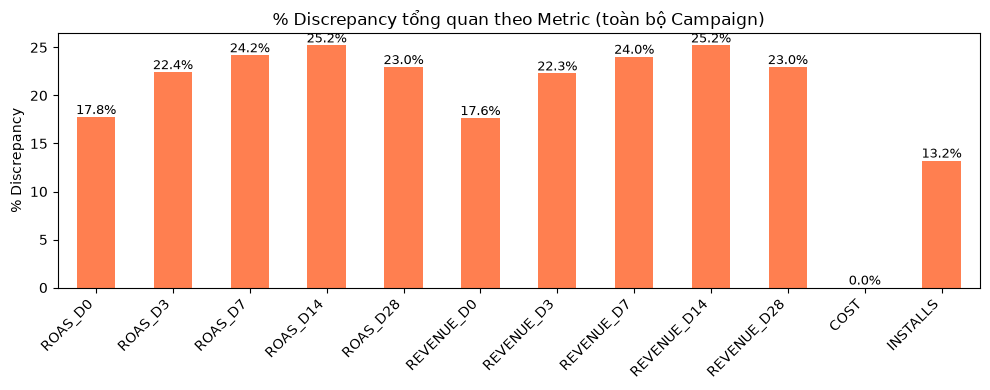

In [14]:
eda.plot_rel_diff_boxplot(detail)
eda.plot_overall_discrepancy_bar(summary_overall)

### 8.5. Xu hướng theo thời gian
Trung bình `ratio = mb/adj` mỗi ngày, theo vài metric đại diện — đường ratio=1 là khớp hoàn toàn.

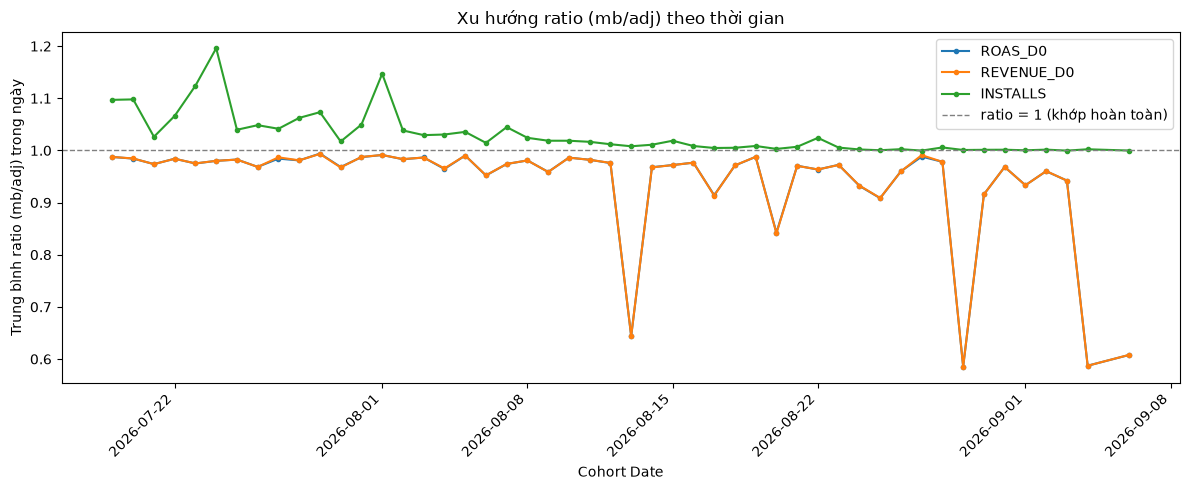

In [15]:
eda.plot_ratio_trend(detail, metrics=["ROAS_D0", "REVENUE_D0", "INSTALLS"])